In [11]:
"""
ETH 1H Price Analysis — past 30 days
Stats: excess kurtosis, skewness, quantile range, stationarity, autocorrelation
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

# ── 1. Fetch data ─────────────────────────────────────────────────────────────

print("Fetching ETH-USD 15m data for the past 30 days …\n")
ticker = yf.Ticker("ETH-USD")
df = ticker.history(period="30d", interval="15m")

if df.empty:
    raise RuntimeError("No data returned. Check your internet connection.")

prices = df["Close"].dropna()
print(f"Retrieved {len(prices)} hourly bars  "
      f"({prices.index[0].date()} → {prices.index[-1].date()})\n")

# ── 2. Return series (log returns) ────────────────────────────────────────────

log_returns = np.log(prices / prices.shift(1)).dropna()

# ── 3. Descriptive stats ──────────────────────────────────────────────────────

sep = "─" * 55

print(sep)
print("  DISTRIBUTIONAL STATISTICS  (log returns)")
print(sep)

excess_kurt = stats.kurtosis(log_returns, fisher=True)   # Fisher = excess
skewness    = stats.skew(log_returns)

print(f"  Observations     : {len(log_returns)}")
print(f"  Mean             : {log_returns.mean():.6f}")
print(f"  Std dev          : {log_returns.std():.6f}")
print(f"  Skewness         : {skewness:+.4f}  "
      f"({'left-skewed' if skewness < 0 else 'right-skewed'})")
print(f"  Excess kurtosis  : {excess_kurt:+.4f}  "
      f"({'fat-tailed (leptokurtic)' if excess_kurt > 0 else 'thin-tailed (platykurtic)'})")

# Normality test for context
_, jb_p = stats.jarque_bera(log_returns)
print(f"  Jarque-Bera p    : {jb_p:.4f}  "
      f"({'reject normality' if jb_p < 0.05 else 'cannot reject normality'} @ 5%)")

# ── 4. Quantile return range ──────────────────────────────────────────────────

print(f"\n{sep}")
print("  QUANTILE RETURN RANGE  (log returns)")
print(sep)

quantiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
q_vals = np.quantile(log_returns, quantiles)

for q, v in zip(quantiles, q_vals):
    bar = "█" * int(abs(v) / log_returns.std() * 10)
    print(f"  Q{q*100:>5.1f}%  {v:+.5f}  {bar}")

iqr = np.quantile(log_returns, 0.75) - np.quantile(log_returns, 0.25)
print(f"\n  IQR  (Q75 − Q25)  : {iqr:.6f}")
print(f"  Q99 − Q01 range   : {q_vals[-1] - q_vals[0]:.6f}")

# ── 5. Stationarity tests ─────────────────────────────────────────────────────
#   ADF & KPSS on PRICE (non-stationary in levels is what we expect to confirm)
#   and on RETURNS (should be stationary)

print(f"\n{sep}")
print("  STATIONARITY TESTS")
print(sep)

def run_adf(series, label):
    result = adfuller(series, autolag="AIC")
    stat, p, lags, nobs = result[0], result[1], result[2], result[3]
    cv1, cv5, cv10 = result[4]["1%"], result[4]["5%"], result[4]["10%"]
    verdict = "STATIONARY" if p < 0.05 else "NON-STATIONARY"
    print(f"\n  ADF — {label}")
    print(f"    Test stat   : {stat:.4f}  (crit values  1%:{cv1:.2f}  5%:{cv5:.2f}  10%:{cv10:.2f})")
    print(f"    p-value     : {p:.4f}  → {verdict} @ 5% (H₀: unit root present)")
    print(f"    Lags used   : {lags}  |  N obs: {nobs}")

def run_kpss(series, label):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat, p, lags, cv = kpss(series, regression="c", nlags="auto")
    verdict = "NON-STATIONARY" if p < 0.05 else "STATIONARY"
    print(f"\n  KPSS — {label}")
    print(f"    Test stat   : {stat:.4f}  (crit values  1%:{cv['1%']:.3f}  5%:{cv['5%']:.3f}  10%:{cv['10%']:.3f})")
    print(f"    p-value     : {p:.4f}  → {verdict} @ 5% (H₀: trend-stationary)")
    print(f"    Lags used   : {lags}")

run_adf(prices,       "Price series")
run_kpss(prices,      "Price series")
run_adf(log_returns,  "Log-return series")
run_kpss(log_returns, "Log-return series")

# ── 6. Autocorrelation tests (lags 1–5) ───────────────────────────────────────
#   Ljung-Box on returns (linear autocorrelation)
#   Durbin-Watson for lag-1 summary
#   Also check squared returns for volatility clustering (ARCH effects)

print(f"\n{sep}")
print("  AUTOCORRELATION TESTS  (log returns, lags 1–5)")
print(sep)

# Raw ACF values
acf_vals = acf(log_returns, nlags=5, fft=True)[1:6]  # skip lag-0
print("\n  Sample ACF:")
for lag, a in enumerate(acf_vals, 1):
    bar = "█" * int(abs(a) * 50)
    sign = "+" if a >= 0 else "-"
    print(f"    Lag {lag}: {a:+.5f}  {bar}")

# Ljung-Box (returns)
lb = acorr_ljungbox(log_returns, lags=range(1, 6), return_df=True)
print("\n  Ljung-Box Q-test  (H₀: no autocorrelation up to lag k):")
print(f"  {'Lag':>4}  {'LB stat':>10}  {'p-value':>10}  {'Verdict':>20}")
for lag, row in lb.iterrows():
    verdict = "autocorrelation detected" if row["lb_pvalue"] < 0.05 else "no autocorrelation"
    print(f"  {lag:>4}  {row['lb_stat']:>10.4f}  {row['lb_pvalue']:>10.4f}  {verdict:>20}")

# Ljung-Box on squared returns (volatility clustering / ARCH effects)
lb_sq = acorr_ljungbox(log_returns**2, lags=range(1, 6), return_df=True)
print("\n  Ljung-Box Q-test on SQUARED returns  (ARCH / volatility clustering):")
print(f"  {'Lag':>4}  {'LB stat':>10}  {'p-value':>10}  {'Verdict':>20}")
for lag, row in lb_sq.iterrows():
    verdict = "clustering detected" if row["lb_pvalue"] < 0.05 else "no clustering"
    print(f"  {lag:>4}  {row['lb_stat']:>10.4f}  {row['lb_pvalue']:>10.4f}  {verdict:>20}")

# Durbin-Watson (lag-1 serial correlation summary)
dw = durbin_watson(log_returns)
print(f"\n  Durbin-Watson stat: {dw:.4f}  "
      f"(≈2 → no autocorrelation, <2 → positive, >2 → negative)")

print(f"\n{sep}\n")

Fetching ETH-USD 15m data for the past 30 days …

Retrieved 2813 hourly bars  (2026-04-14 → 2026-05-13)

───────────────────────────────────────────────────────
  DISTRIBUTIONAL STATISTICS  (log returns)
───────────────────────────────────────────────────────
  Observations     : 2812
  Mean             : -0.000016
  Std dev          : 0.002250
  Skewness         : -0.3362  (left-skewed)
  Excess kurtosis  : +7.1835  (fat-tailed (leptokurtic))
  Jarque-Bera p    : 0.0000  (reject normality @ 5%)

───────────────────────────────────────────────────────
  QUANTILE RETURN RANGE  (log returns)
───────────────────────────────────────────────────────
  Q  1.0%  -0.00644  ████████████████████████████
  Q  5.0%  -0.00352  ███████████████
  Q 10.0%  -0.00223  █████████
  Q 25.0%  -0.00106  ████
  Q 50.0%  -0.00002  
  Q 75.0%  +0.00108  ████
  Q 90.0%  +0.00228  ██████████
  Q 95.0%  +0.00325  ██████████████
  Q 99.0%  +0.00644  ████████████████████████████

  IQR  (Q75 − Q25)  : 0.002143
  Q99

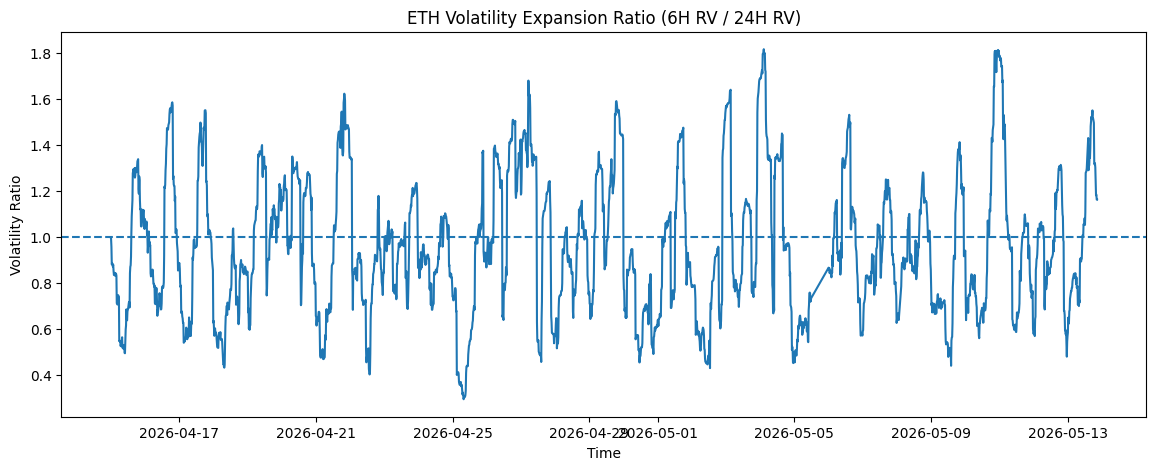

In [13]:
# ── 3. Realized volatility ────────────────────────────────────────────────────

# 15m bars:
# 4 bars/hour
# 96 bars/day

rv_6h = log_returns.rolling(24).std()     # 6-hour realized vol
rv_24h = log_returns.rolling(96).std()    # 24-hour realized vol

# Volatility expansion ratio
vol_ratio = rv_6h / rv_24h

# ── 7. VOLATILITY REGIME DETECTOR ─────────────────────────────────────────────

plt.figure(figsize=(14, 5))

plt.plot(vol_ratio.index, vol_ratio.values)

plt.axhline(1.0, linestyle="--")

plt.title("ETH Volatility Expansion Ratio (6H RV / 24H RV)")
plt.xlabel("Time")
plt.ylabel("Volatility Ratio")

plt.show()